In [ ]:
import os
import glob
import pandas as pd
import numpy as np

def load_condition_tables(
    data_dir="data",
    strength_col="scaled_weight",
    pval_col="cellphone_pvals",
    pval_threshold=None,
):
    paths = sorted(glob.glob(os.path.join(data_dir, "*.csv")))
    if not paths:
        raise FileNotFoundError(f"No CSV files found in: {data_dir}/")

    frames = []
    for path in paths:
        df = pd.read_csv(path)

        if "Diagnosis" in df.columns:
            df["condition"] = df["Diagnosis"].astype(str)
        else:
            df["condition"] = os.path.splitext(os.path.basename(path))[0]

        if strength_col in df.columns:
            df["strength"] = df[strength_col]
        elif "lrscore" in df.columns:
            df["strength"] = df["lrscore"]
        else:
            raise ValueError(f"{os.path.basename(path)}: no '{strength_col}' or 'lrscore' column found.")

        if pval_threshold is not None:
            if pval_col not in df.columns:
                raise ValueError(f"{os.path.basename(path)}: p-value column '{pval_col}' not found.")
            df = df[df[pval_col] <= pval_threshold].copy()

        frames.append(df)

    all_df = pd.concat(frames, ignore_index=True)

    required = ["ligand", "receptor", "Slide", "condition", "strength"]
    missing = [c for c in required if c not in all_df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    group_cols = ["condition", "ligand", "receptor"]
    agg = (
        all_df
        .groupby(group_cols, as_index=False)
        .agg(
            mean_strength=("strength", "mean"),
            median_strength=("strength", "median"),
            n_rows=("strength", "size"),
            n_slides=("Slide", pd.Series.nunique),
        )
    )

    meta_candidates = [
        "pathway_name",
        "interaction_name",
        "gene_a",
        "gene_b",
        "annotation",
        "category",
        "evidence",
        "spec_weight",
        "specificity_rank",
    ]
    meta_cols = [c for c in meta_candidates if c in all_df.columns]

    if meta_cols:
        meta = (
            all_df[group_cols + meta_cols]
            .drop_duplicates(subset=group_cols, keep="first")
        )
        agg = agg.merge(meta, on=group_cols, how="left")

    if "interaction_name" not in agg.columns:
        agg["interaction_name"] = agg["ligand"].astype(str) + "_" + agg["receptor"].astype(str)

    tables = {
        cond: sub.drop(columns=["condition"]).sort_values("mean_strength", ascending=False).reset_index(drop=True)
        for cond, sub in agg.groupby("condition", sort=True)
    }

    return tables


cond_tabs = load_condition_tables(
    data_dir="data",
    strength_col="scaled_weight",
    pval_threshold=None,
)

cond_tabs["AD"].head()

,ligand,receptor,mean_strength,median_strength,n_rows,n_slides,spec_weight,specificity_rank,interaction_name
0,COL18A1,ITGA5,1.944618,1.944618,1,1,0.470267,6.233965e-10,COL18A1_ITGA5
1,SPON2,ITGB1,1.112418,1.094978,5,1,0.154745,7.369620e-05,SPON2_ITGB1
2,FN1,ITGA5_ITGB1,1.080340,0.776434,3,1,0.398344,2.630121e-10,FN1_ITGA5_ITGB1
3,ANGPTL4,TIE1,1.029480,1.025553,4,1,0.102419,1.689537e-03,ANGPTL4_TIE1
4,NPY,ADRB2,1.020804,1.017250,6,1,0.027531,1.515166e-01,NPY_ADRB2


In [60]:
threshold = 0.0

cond_tabs = {
    cond: tbl[tbl["mean_strength"] >= threshold].reset_index(drop=True)
    for cond, tbl in cond_tabs.items()
}

for condition, table in cond_tabs.items():
    print(f"{condition}: {len(table)}")

AD: 768
Control: 673
earlyAD: 691


In [54]:
cond_tabs["earlyAD"]

,ligand,receptor,mean_strength,median_strength,n_rows,n_slides,spec_weight,specificity_rank,interaction_name
0,APLN,APLNR,0.670366,0.670366,2,1,0.05803,0.000054,APLN_APLNR


In [55]:
cond_tabs["Control"]

,ligand,receptor,mean_strength,median_strength,n_rows,n_slides,spec_weight,specificity_rank,interaction_name
0,S100A4,ERBB3,1.173368,1.173368,1,1,0.287936,6.753971e-07,S100A4_ERBB3
1,APOC2,LRP2,0.647337,0.638037,4,1,0.106675,1.781650e-03,APOC2_LRP2
2,MDK,LRP2,0.643470,0.645771,3,1,0.078551,5.246223e-03,MDK_LRP2


/Users/dustinm/Projects/research/ma-lab/TissueAgent/.venv/lib/python3.12/site-packages/matplotlib_venn/_util.py:62: UserWarning: venn3_unweighted is deprecated. Use venn3 with the appropriate layout_algorithm instead.
  warnings.warn(


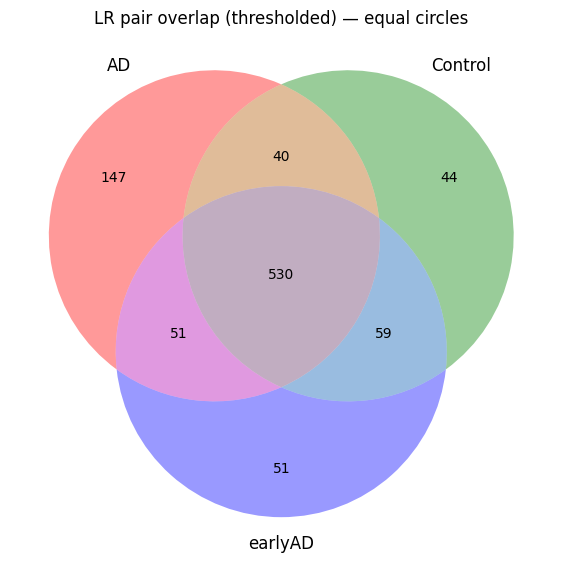

In [62]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn3_unweighted

def _as_lr_set(df):
    if "interaction_name" in df.columns:
        return set(df["interaction_name"].astype(str))
    return set((df["ligand"].astype(str) + "_" + df["receptor"].astype(str)).tolist())

ad = _as_lr_set(cond_tabs["AD"])
control = _as_lr_set(cond_tabs["Control"])
earlyad = _as_lr_set(cond_tabs["earlyAD"])

plt.figure(figsize=(7, 7))
venn3_unweighted([ad, control, earlyad], set_labels=("AD", "Control", "earlyAD"))
plt.title("LR pair overlap (thresholded) — equal circles")
plt.show()


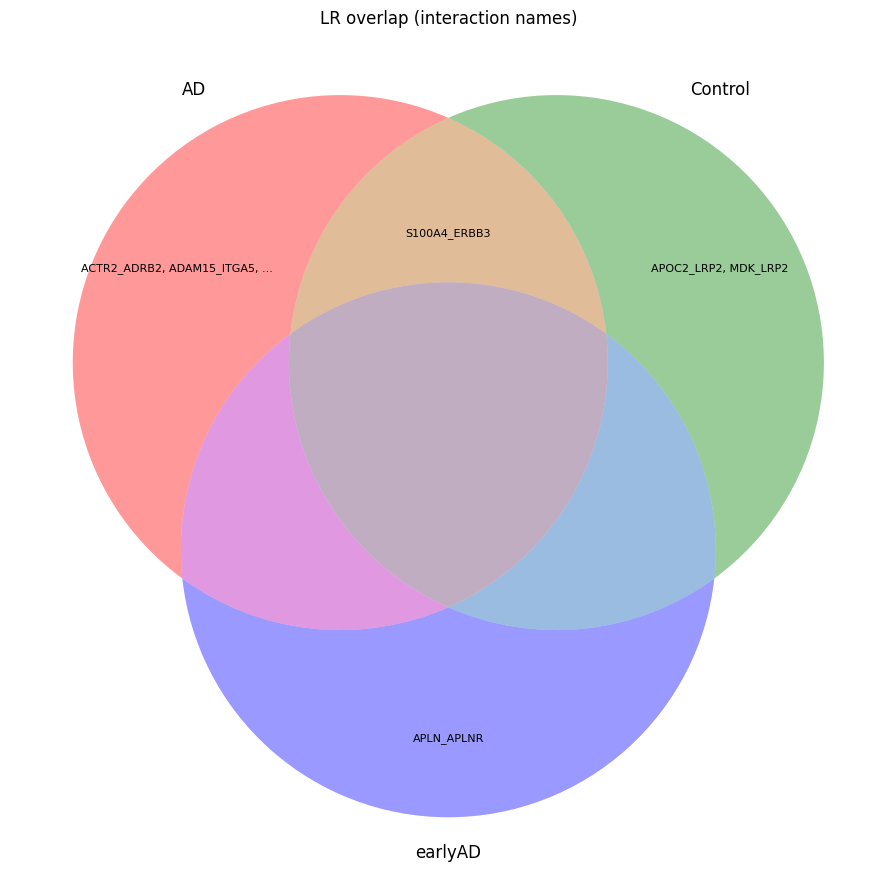

In [47]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn3
from matplotlib_venn.layout.venn3 import DefaultLayoutAlgorithm
import textwrap

def _lr_set(df):
    if "interaction_name" in df.columns:
        return set(df["interaction_name"].astype(str))
    return set((df["ligand"].astype(str) + "_" + df["receptor"].astype(str)).tolist())

def _region_items(A, B, C):
    return {
        "100": sorted(A - B - C),
        "010": sorted(B - A - C),
        "001": sorted(C - A - B),
        "110": sorted((A & B) - C),
        "101": sorted((A & C) - B),
        "011": sorted((B & C) - A),
        "111": sorted(A & B & C),
    }

def _fit_text(fig, ax, patch, xy, items, fontsize):
    if patch is None or not items:
        return ""

    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    bbox = patch.get_window_extent(renderer=renderer)
    if bbox.width <= 10 or bbox.height <= 10:
        return ""

    width_chars = max(10, min(70, int(bbox.width / (fontsize * 0.62))))
    x, y = xy

    n = len(items)
    while n >= 1:
        base = ", ".join(items[:n])
        if n < len(items):
            base = base + ", ..."
        txt = textwrap.fill(base, width=width_chars, break_long_words=False, break_on_hyphens=False)

        t = ax.text(x, y, txt, ha="center", va="center", fontsize=fontsize, alpha=0)
        fig.canvas.draw()
        tb = t.get_window_extent(renderer=renderer)
        t.remove()

        if tb.width <= bbox.width * 0.92 and tb.height <= bbox.height * 0.92:
            return txt
        n -= 1

    return "..."

def plot_pretty_venn_names(cond_tabs, keys=("AD", "Control", "earlyAD"), fontsize=8, figsize=(14, 9)):
    A = _lr_set(cond_tabs[keys[0]])
    B = _lr_set(cond_tabs[keys[1]])
    C = _lr_set(cond_tabs[keys[2]])

    fig, ax = plt.subplots(figsize=figsize)

    layout = DefaultLayoutAlgorithm(fixed_subset_sizes=(1, 1, 1, 1, 1, 1, 1))
    v = venn3([A, B, C], set_labels=keys, ax=ax, layout_algorithm=layout)

    region_to_text = _region_items(A, B, C)

    for region_id, items in region_to_text.items():
        patch = v.get_patch_by_id(region_id)
        label = v.get_label_by_id(region_id)

        if label is None:
            continue

        xy = label.get_position()
        label.set_text("")

        txt = _fit_text(fig, ax, patch, xy, items, fontsize=fontsize)
        if patch is not None and txt:
            ax.text(xy[0], xy[1], txt, ha="center", va="center", fontsize=fontsize)

    ax.set_title("LR overlap (interaction names)")
    plt.tight_layout()
    plt.show()

plot_pretty_venn_names(cond_tabs, keys=("AD", "Control", "earlyAD"), fontsize=8, figsize=(14, 9))
